## **1 - Setup & Imports**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import string
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
from collections import Counter
plt.rcParams.update({'figure.dpi':120,'figure.figsize':(14,5),
                     'axes.spines.top':False,'axes.spines.right':False})
print('Libraries loaded!')

import sys, os
sys.path.append('..')
sys.path.append('.')

Libraries loaded!


## **2 - Generate & Load Dataset**

In [ ]:
import subprocess
result = subprocess.run(
    ['python', 'data_generator.py'],   
    capture_output=True, text=True
)
print(result.stdout or result.stderr)

âœ… Dataset saved to 'data\grievances_dataset.csv'
   Rows            : 3,000
   Columns         : ['complaint_id', 'date', 'complaint_text', 'department', 'sentiment', 'city', 'priority_level', 'resolution_days', 'is_repeat_complaint', 'submission_channel']
   Departments     : ['Healthcare', 'Water', 'Education', 'Electricity', 'Roads', 'Transport', 'Sanitation']
   Sentiments      : {'Negative': 1405, 'Neutral': 853, 'Critical/Urgent': 650, 'Positive': 92}
   Cities          : 8 cities



#### load dataset..

In [11]:
df_raw = pd.read_csv('data/grievances_dataset.csv')
print('Shape:', df_raw.shape)
print('Columns:', df_raw.columns.tolist())
df_raw.head(3)

Shape: (3000, 10)
Columns: ['complaint_id', 'date', 'complaint_text', 'department', 'sentiment', 'city', 'priority_level', 'resolution_days', 'is_repeat_complaint', 'submission_channel']


,complaint_id,date,complaint_text,department,sentiment,city,priority_level,resolution_days,is_repeat_complaint,submission_channel
0,CMP00001,2022-04-15,Medicines not available at government dispensa...,Healthcare,Negative,Mumbai,3,38,1,online
1,CMP00002,2023-10-28,The water coming from the tap is extremely dir...,Water,Negative,Ahmedabad,3,15,1,app
2,CMP00003,2022-12-15,Government school has no teachers for 26 month...,Education,Critical/Urgent,Chennai,5,3,0,app


## **3 - Data Quality Checks**

In [12]:
print('=== Missing Values ===')
print(df_raw.isnull().sum())
print('\n=== Duplicates:', df_raw.duplicated().sum())
print('\n=== Describe:')
df_raw.describe()

=== Missing Values ===
complaint_id           0
date                   0
complaint_text         0
department             0
sentiment              0
city                   0
priority_level         0
resolution_days        0
is_repeat_complaint    0
submission_channel     0
dtype: int64

=== Duplicates: 0

=== Describe:


,priority_level,resolution_days,is_repeat_complaint
count,3000.000000,3000.000000,3000.000000
mean,3.318333,19.076000,0.264000
std,1.184679,13.562652,0.440873
min,1.000000,1.000000,0.000000
25%,2.000000,7.000000,0.000000
50%,3.000000,16.000000,0.000000
75%,4.000000,31.000000,1.000000
max,5.000000,45.000000,1.000000


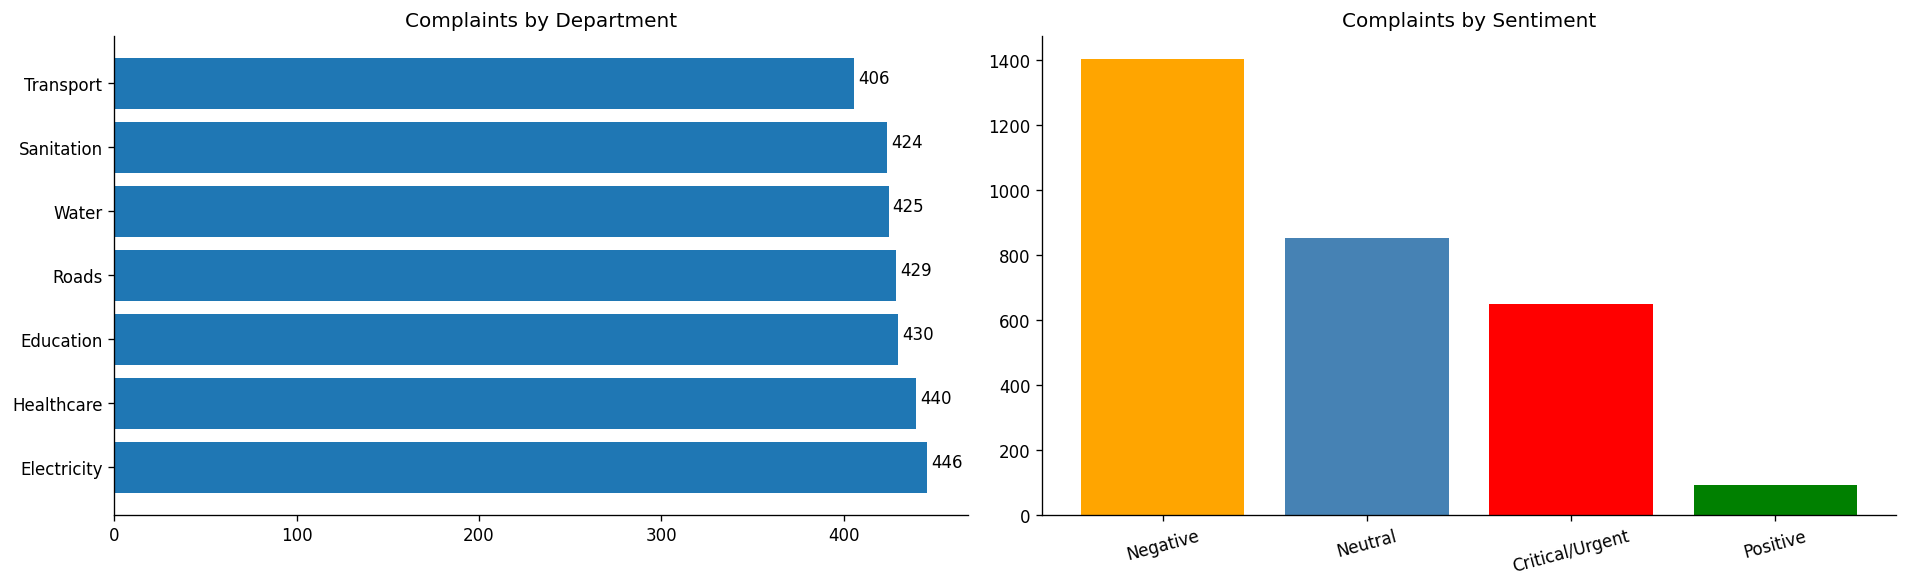

In [ ]:
import os
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=(16,5))

#  Plot 1: Department Distribution
plt.subplot(1,2,1)
dept_counts = df_raw['department'].value_counts()
plt.barh(dept_counts.index, dept_counts.values)

# Show values
for i, v in enumerate(dept_counts.values):
    plt.text(v+2, i, str(v))

plt.title("Complaints by Department")


#  Plot 2: Sentiment Distribution
plt.subplot(1,2,2)
sent_counts = df_raw['sentiment'].value_counts()
cols=["orange","steelblue","red","green"]
plt.bar(sent_counts.index, sent_counts.values,color=cols[:len(sent_counts)])
plt.title("Complaints by Sentiment")
plt.xticks(rotation=15)
# Layout
plt.tight_layout()

# Save
os.makedirs('reports', exist_ok=True)
plt.savefig('reports/01_class_distribution.png')

plt.show()